# Reproducing Squidiff Paper: Figure 2 — iPSC Differentiation Prediction

**Paper**: He, S., Zhu, Y., Tavakol, D.N. et al. *Squidiff: predicting cellular development and responses to perturbations using a diffusion model.* Nat Methods (2025). https://doi.org/10.1038/s41592-025-02877-y

## Paper Context

**In-text citation (paper, Results section):**
> "Applied to a public single-cell transcriptomics dataset of iPSC differentiation, Squidiff effectively captures the state changes from iPSCs to mesendoderm and definitive endoderm cells from day 0 to day 3. The model was trained on data only from day 0 and day 3."

**Figure 2 caption:**
> "Fig. 2 | Squidiff predicts cell differentiation. b, UMAP visualization of training datasets. c, Pearson correlation plots comparing model-predicted and ground truth scRNA-seq data across different days. d, Heatmap of the top 15 differentially expressed genes across time (days 0 to 3). e, Pseudotime analysis showing cell density distributions. g, Comparison of Squidiff against scGen and trajectory inference methods."

## This Notebook

This notebook loads a trained Squidiff model and generates transcriptomic predictions for iPSC differentiation intermediate states (day 1, day 2) from the day 0 starting point. The predictions are evaluated against ground truth data using Pearson correlation and R^2 metrics, and visualized via UMAP, heatmaps, and pseudotime plots corresponding to Figure 2 of the paper.

**Prerequisites**:
- `diff_train_raw.h5ad` and `test_adata_raw.h5ad` — generated by `preprocess_fig2_data.ipynb`
- `checkpoints/<run>/model.pt` or `model_0.9999.pt` — trained model checkpoint saved by `train_squidiff.py`
- `plot_util.py` — plotting utility (must be placed in `Squidiff_reproducibility/`)


## 0. Environment Setup and Path Configuration

This section imports all required libraries and configures display settings. The `sys.path` is extended to include the Squidiff source directory (`../Squidiff`) so that `sample_squidiff` and `plot_util` can be imported directly. The working directory must be `Squidiff_reproducibility/`.


In [2]:
import sys
import os

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import anndata
import muon as mu
import seaborn as sns
import torch
from scipy import sparse
import matplotlib.font_manager
from matplotlib import rcParams

cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, "Squidiff")):
    REPO_ROOT = cwd
elif os.path.exists(os.path.join(os.path.dirname(cwd), "Squidiff")):
    REPO_ROOT = os.path.dirname(cwd)
else:
    raise FileNotFoundError("Could not locate repo root containing the Squidiff package.")

sys.path.insert(0, REPO_ROOT)
sys.path.insert(0, os.path.join(REPO_ROOT, "Squidiff_reproducibility", "utils"))

import sample_squidiff
import plot_util

import warnings
warnings.filterwarnings('ignore')

font_list = []
for path in matplotlib.font_manager.findSystemFonts():
    try:
        font_list.append(matplotlib.font_manager.get_font(path).family_name)
    except Exception:
        pass
font_list = set(font_list)
plot_font = 'DejaVu Sans' if 'DejaVu Sans' in font_list else 'FreeSans'
rcParams['font.family'] = plot_font
rcParams.update({'font.size': 10, 'figure.dpi': 300})

print(f'Repo root: {REPO_ROOT}')
print(f'Working directory: {os.getcwd()}')


/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


Repo root: /home/anniehuang/Squidiff
Working directory: /home/anniehuang/Squidiff/scripts


## 1. Load Trained Squidiff Model

The trained model checkpoint is loaded using `sample_squidiff.sampler`. The model was trained on iPSC differentiation data with 203 genes (top 200 HVGs + NANOG, T, GATA6), consistent with the paper's Methods section.

**Key parameters**:
- `gene_size` is loaded from `model_spec.json` and must match the processed RNA feature dimension used by the checkpoint.
- `use_drug_structure = False` — no drug compound encoding for this task


In [ ]:
# Optional training commands.
# Run exactly one of these before evaluation if you need to train a checkpoint.
# !python -m Squidiff.train_squidiff --config config/rna.yaml
# !python -m Squidiff.train_squidiff --config config/rna-atac.yaml

In [18]:
# Load ckpt
model_path = os.path.join(REPO_ROOT, "checkpoints", "20260426_003254", "best_model_0.9999.pt")
sampler = sample_squidiff.sampler(model_path=model_path)
model_spec = dict(sampler.arg)
MODEL_DEVICE = next(sampler.model.parameters()).device

print('Model loaded successfully.')
print(f'Model path: {model_path}')
print(f'rna_only: {model_spec["rna_only"]}')
print(f'RNA dim: {model_spec["gene_size"]}')
print(f'ATAC dim: {model_spec.get("atac_input_size")}')
print(f'Model device: {MODEL_DEVICE}')

load model and diffusion...
diffusion num of steps =  1000
Model loaded successfully.
Model path: /home/anniehuang/Squidiff/checkpoints/20260426_003254/best_model_0.9999.pt
rna_only: True
RNA dim: 100
ATAC dim: None
Model device: cuda:0


## 2. Encode Training Data and Validate Reconstruction

The semantic encoder maps training cells into the latent space ($z_{sem}$). The diffusion model then reconstructs the gene expression from this latent representation. This step verifies that the model has learned a meaningful encoding of training data and produces $x_T$ using the model's true forward diffusion process, corresponding to Fig. 1c of the paper.


In [4]:
tr_fn = os.path.join(REPO_ROOT, "data", "mouse", "processed", "mouse_train.h5mu")
ts_fn = os.path.join(REPO_ROOT, "data", "mouse", "processed", "mouse_test.h5mu")
output_dir = os.path.join(REPO_ROOT, "results")
os.makedirs(output_dir, exist_ok=True)

def to_numpy_matrix(matrix):
    if sparse.issparse(matrix):
        return matrix.toarray()
    return np.asarray(matrix)

def adata_to_tensor(adata):
    return torch.tensor(to_numpy_matrix(adata.X), dtype=torch.float32, device=MODEL_DEVICE)

def load_data_object(data_path):
    suffix = os.path.splitext(data_path)[1].lower()
    if suffix == ".h5mu":
        return mu.read_h5mu(data_path)
    if suffix == ".h5ad":
        return sc.read_h5ad(data_path)
    raise ValueError(f"Unsupported input file type: {suffix}")

def extract_rna_adata(data_obj):
    if hasattr(data_obj, "mod"):
        return data_obj["rna"].copy()
    return data_obj.copy()

def extract_atac_adata(data_obj):
    if not hasattr(data_obj, "mod"):
        return None
    return data_obj["atac"].copy()

def ensure_paired_subset(rna_adata, atac_adata, obs_names=None, group=None):
    if obs_names is None:
        if group is None:
            obs_names = rna_adata.obs_names
        else:
            obs_names = rna_adata.obs_names[rna_adata.obs["Group"] == group]
    obs_names = rna_adata.obs_names.intersection(obs_names)
    rna_subset = rna_adata[obs_names].copy()
    if atac_adata is None:
        return rna_subset, None
    atac_obs = atac_adata.obs_names.intersection(obs_names)
    common = rna_subset.obs_names.intersection(atac_obs)
    return rna_subset[common].copy(), atac_adata[common].copy()

def encode_semantic_latent(rna_adata, atac_adata=None):
    x_rna = adata_to_tensor(rna_adata)
    with torch.no_grad():
        if model_spec["rna_only"]:
            return sampler.model.encoder(x_rna)
        if atac_adata is None:
            raise ValueError("ATAC input is required for a multiomics checkpoint.")
        x_atac = adata_to_tensor(atac_adata)
        return sampler.model.encoder(x_rna, x_atac)

def plot_adata_pca(adata, title):
    plot_util.plot_pca(
        to_numpy_matrix(adata.X),
        label=adata.obs["Group"],
        size=3,
        alpha=0.8,
        colorlist=['#3145a8', '#40a8f7', '#f5bf36', '#fa2616'],
        color_label=[0, 1, 2, 3],
        title=title,
    )

train_data = load_data_object(tr_fn)
test_data = load_data_object(ts_fn)
train_rna_adata = sampler.align_rna_adata(extract_rna_adata(train_data))
train_atac_adata = extract_atac_adata(train_data)
test_rna_adata = sampler.align_rna_adata(extract_rna_adata(test_data))
test_atac_adata = extract_atac_adata(test_data)

if not model_spec["rna_only"]:
    if train_atac_adata is None or test_atac_adata is None:
        raise ValueError("This checkpoint expects multiomics input, but the dataset does not expose ['rna'] and ['atac'].")
    train_atac_adata = sampler.align_atac_adata(train_atac_adata)
    test_atac_adata = sampler.align_atac_adata(test_atac_adata)
else:
    train_atac_adata = None
    test_atac_adata = None

train_rna_paired, train_atac_paired = ensure_paired_subset(train_rna_adata, train_atac_adata)
test_rna_paired, test_atac_paired = ensure_paired_subset(test_rna_adata, test_atac_adata)

z_sem = encode_semantic_latent(train_rna_paired, train_atac_paired)
scrnas_pred = sampler.pred(z_sem)
train_rna_tensor = adata_to_tensor(train_rna_paired)
x_T = sampler.get_diffused_data(
    sampler.model,
    x=train_rna_tensor,
    t=999,
    model_kwargs={
        'x_start': train_rna_tensor,
        'z_mod': z_sem,
    },
)['sample']

print(f'Train RNA shape: {train_rna_paired.shape}')
print(f'Test RNA shape: {test_rna_paired.shape}')
if train_atac_paired is not None:
    print(f'Train ATAC shape: {train_atac_paired.shape}')
    print(f'Test ATAC shape: {test_atac_paired.shape}')


Train RNA shape: (9358, 100)
Test RNA shape: (14672, 100)


## 3. PCA Visualization of Semantic Latent Space ($z_{sem}$)

PCA is applied to the semantic latent variable $z_{sem}$ to verify that day 0 (blue) and day 3 (red) training cells form distinct clusters in latent space. Clear separation indicates that the encoder has captured the differentiation direction. This corresponds to Fig. 2b of the paper.


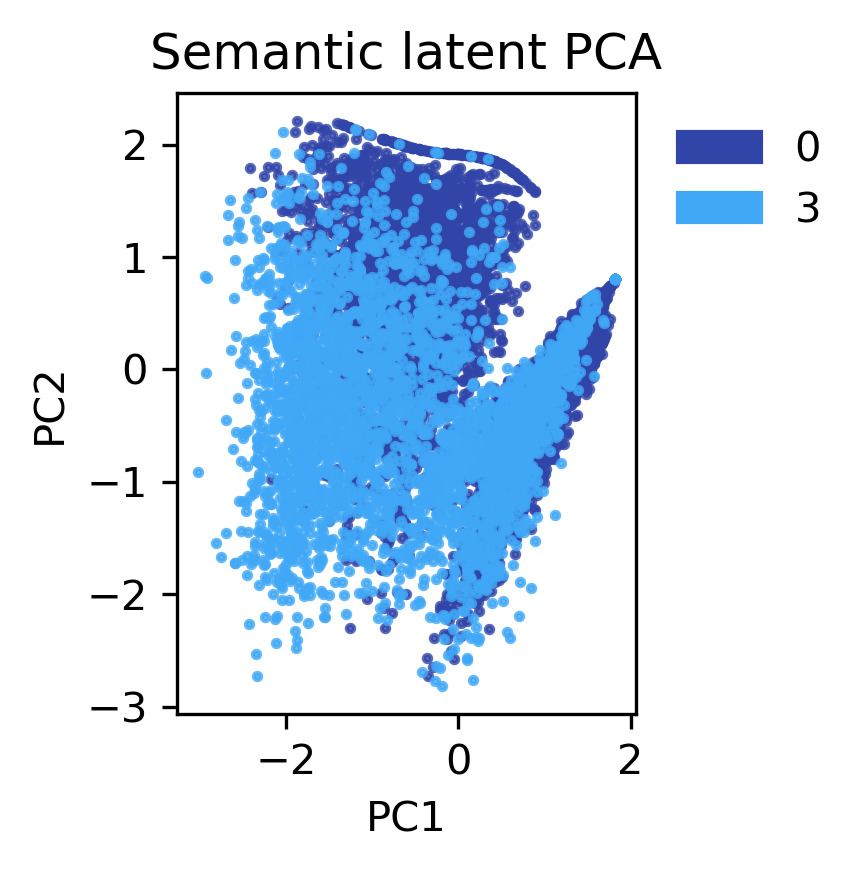

In [5]:
plot_util.plot_pca(
    z_sem,
    label=train_rna_paired.obs['Group'],
    size=3,
    alpha=0.8,
    colorlist=['#3145a8', '#40a8f7', '#f5bf36', '#fa2616'],
    color_label=[0, 1, 2, 3],
    title='Semantic latent PCA',
)


In [ ]:
# TODO: leiden color by group
plot_util.plot_UMAP(
    z_sem,
    label=train_rna_paired.obs['Group'],
    size=3,
    alpha=0.8,
    colorlist=['#3145a8', '#40a8f7', '#f5bf36', '#fa2616'],
    color_label=[0, 1, 2, 3],
    title='Semantic latent PCA',
)


## 4. PCA Visualization of Stochastic Component ($x_T$)

PCA of $x_T$ (the Gaussian noise component after the forward diffusion process) should show no clear separation between day 0 and day 3 cells, confirming that $x_T$ captures stochastic variation rather than biological state. This mirrors Fig. 1c (right panel) of the paper.


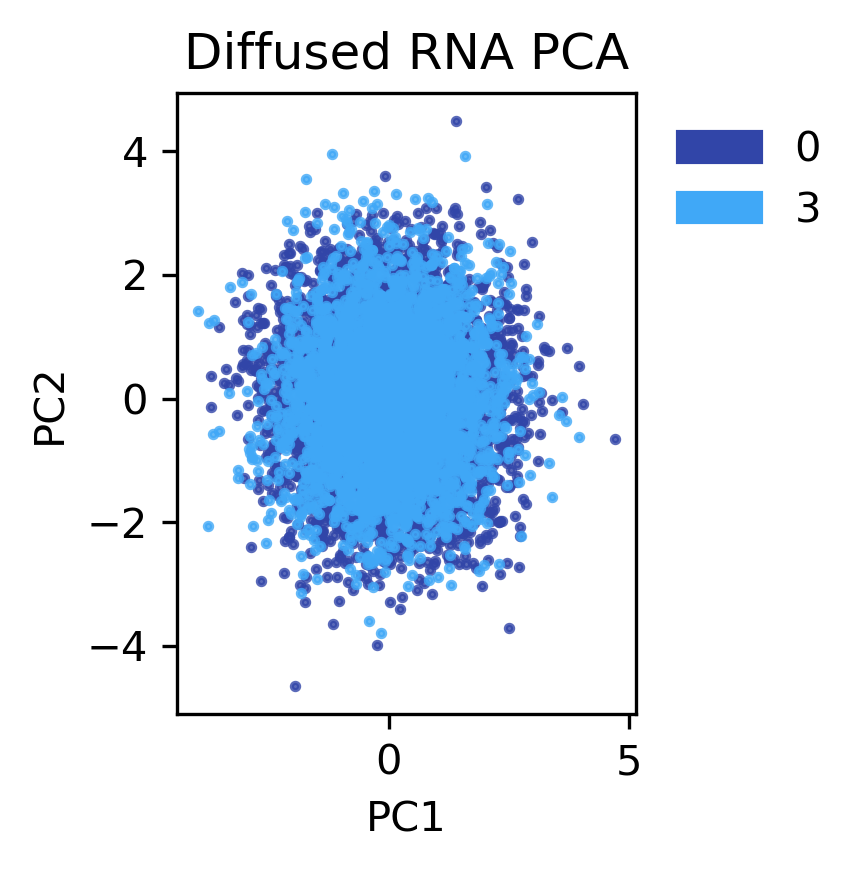

In [6]:
plot_util.plot_pca(
    x_T,
    label=train_rna_paired.obs['Group'],
    size=3,
    alpha=0.8,
    colorlist=['#3145a8', '#40a8f7', '#f5bf36', '#fa2616'],
    color_label=[0, 1, 2, 3],
    title='Diffused RNA PCA',
)


In [ ]:
# TODO: leiden color by group
plot_util.plot_UMAP(
    x_T,
    label=train_rna_paired.obs['Group'],
    size=3,
    alpha=0.8,
    colorlist=['#3145a8', '#40a8f7', '#f5bf36', '#fa2616'],
    color_label=[0, 1, 2, 3],
    title='Diffused RNA PCA',
)

## 5. Compute Differentiation Direction Vector and Predict Intermediate States

The differentiation direction vector $\Delta z_{sem}$ is computed as the mean difference between day 3 and day 0 latent representations in the training data. This vector encodes the average transcriptomic shift associated with differentiation, as described in the paper's Methods (Training Task 1):

> $\Delta z = E(z_{sem}^{day3}) - E(z_{sem}^{day0})$

Starting from day 0 test cells, the model predicts day 1 and day 2 states using scaled linear interpolation along $\Delta z_{sem}$:
- **Day 1** prediction: scale = 1/3
- **Day 2** prediction: scale = 2/3
- **Day 3** prediction: direct encoding from day 3 test cells


In [7]:
if train_atac_paired is not None:
    plot_adata_pca(train_atac_paired, title='Train ATAC PCA')
    plot_adata_pca(test_atac_paired, title='Test ATAC PCA')
else:
    print('RNA-only checkpoint: no ATAC modality to plot.')


RNA-only checkpoint: no ATAC modality to plot.


### 5.1 Load Test Data and Encode Day 0 / Day 3 Cells

Test data (held-out cells from all four days) is loaded and day 0 / day 3 cells are encoded to obtain $z_{sem}^{day0}$ and $z_{sem}^{day3}$. These serve as the starting and ending anchor points for interpolation.


In [8]:
# Get the semantic direction from day 0 to day 3 in the training data.
train_day0_rna, train_day0_atac = ensure_paired_subset(train_rna_paired, train_atac_paired, group=0)
train_day3_rna, train_day3_atac = ensure_paired_subset(train_rna_paired, train_atac_paired, group=3)
z_sem_train_day0 = encode_semantic_latent(train_day0_rna, train_day0_atac)
z_sem_train_day3 = encode_semantic_latent(train_day3_rna, train_day3_atac)
direct_z_sem = z_sem_train_day3.mean(axis=0) - z_sem_train_day0.mean(axis=0)


### 5.2 Run Predictions and Compute Metrics (6 Independent Runs)

Predictions are repeated 6 times to assess variability. For each run, Squidiff generates predicted gene expression for all four time points. Pearson correlation and $R^2$ between predicted and ground truth are computed per day using `sampler.cal_metric()`. Results are saved to `outputs/` for later comparison. This corresponds to Fig. 2c of the paper.


In [9]:
test_day0_rna, test_day0_atac = ensure_paired_subset(test_rna_paired, test_atac_paired, group=0)
test_day3_rna, test_day3_atac = ensure_paired_subset(test_rna_paired, test_atac_paired, group=3)
z_sem_test_day0 = encode_semantic_latent(test_day0_rna, test_day0_atac)
z_sem_test_day3 = encode_semantic_latent(test_day3_rna, test_day3_atac)


### 5.3 Scatter Plot: Predicted vs. Ground Truth Gene Expression (Fig. 2c Style)

A 2x2 panel scatter plot compares the mean predicted gene expression against ground truth for all four prediction scenarios. High correlation along the diagonal indicates accurate prediction of both endpoints and intermediate cellular states.
- **Day 0 → Day 1** (predicted)
- **Day 0 → Day 2** (predicted)
- **Day 0 → Day 3** (predicted)
- **Predicted Day 1 → Day 2** (two-step prediction)


In [19]:
r_all = []
pearsonr_all = []
rna_dim = test_rna_paired.n_vars

for i in range(6):
    sample_interp0 = sampler.pred(z_sem=z_sem_test_day0)
    sample_interp1 = sampler.interp_with_direction(
        z_sem_origin=z_sem_test_day0,
        gene_size=model_spec['gene_size'],
        direction=direct_z_sem,
        scale=1/3,
    )
    sample_interp2 = sampler.interp_with_direction(
        z_sem_origin=z_sem_test_day0,
        gene_size=model_spec['gene_size'],
        direction=direct_z_sem,
        scale=2/3,
    )
    sample_interp3 = sampler.pred(z_sem=z_sem_test_day3)

    for day_name, pred_tensor, truth_group in [
        ('day0', sample_interp0, 0),
        ('day1', sample_interp1, 1),
        ('day2', sample_interp2, 2),
        ('day3', sample_interp3, 3),
    ]:
        r2_, pearsonr_ = sampler.cal_metric(pred_tensor, test_rna_paired[test_rna_paired.obs['Group'] == truth_group])
        r_all.append(['squidiff', i, day_name, r2_])
        pearsonr_all.append(['squidiff', i, day_name, pearsonr_])

r_df = pd.DataFrame(r_all, columns=['model', 'replicate', 'day', 'r2'])
pearson_df = pd.DataFrame(pearsonr_all, columns=['model', 'replicate', 'day', 'pearsonr'])
r_df.to_csv(os.path.join(output_dir, 'fig2_diff_r_all_new.csv'), index=False)
pearson_df.to_csv(os.path.join(output_dir, 'fig2_diff_pearsonr_all_new.csv'), index=False)

print(r_df.groupby('day')['r2'].mean())
print(pearson_df.groupby('day')['pearsonr'].mean())


day
day0    0.999085
day1    0.394928
day2    0.522125
day3    0.998676
Name: r2, dtype: float64
day
day0    0.999909
day1    0.933492
day2    0.944033
day3    0.999914
Name: pearsonr, dtype: float32


## 6. UMAP Visualization of Predicted Cell States (Days 0 to 3)

Predicted gene expression for all four days is pooled (600 cells per day) and visualized jointly via PCA followed by UMAP. Gradual color transitions from blue (day 0) to red (day 3) confirm that Squidiff generates biologically ordered intermediate states. This corresponds to Fig. 2b of the paper.

**Parameters**: PCA 30 components, UMAP n_neighbors=50, min_dist=0.2


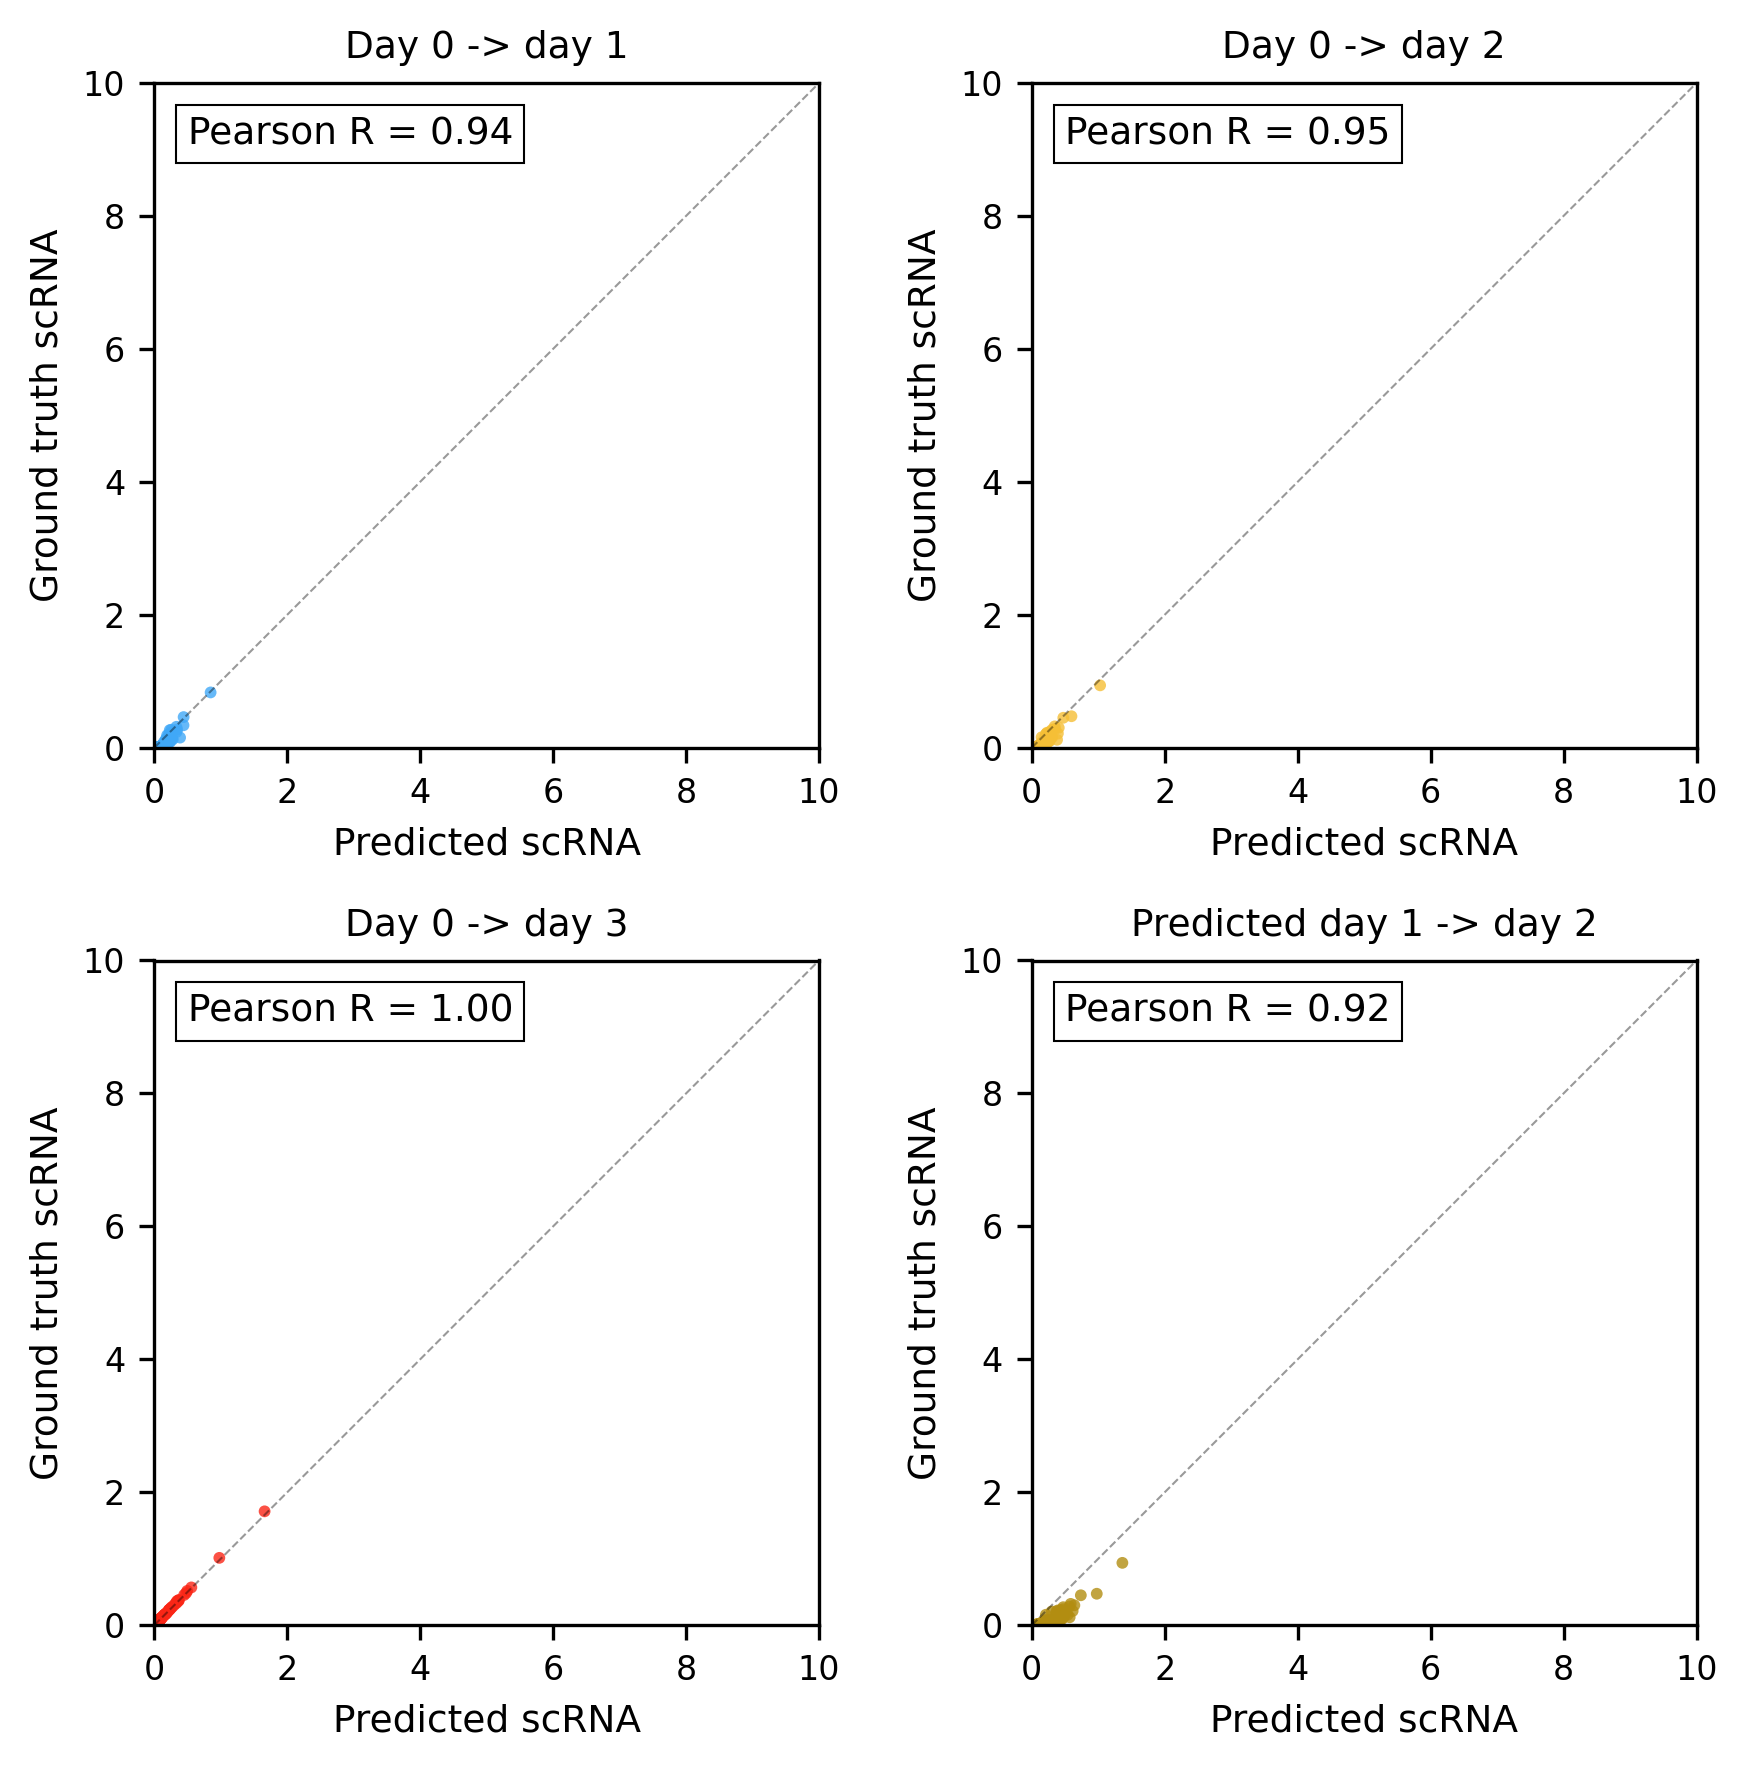

In [20]:
# ========== Fig 2c Style: Scatter Panels ==========
true_day1_np = to_numpy_matrix(test_rna_paired[test_rna_paired.obs['Group'] == 1].X)
true_day2_np = to_numpy_matrix(test_rna_paired[test_rna_paired.obs['Group'] == 2].X)
true_day3_np = to_numpy_matrix(test_rna_paired[test_rna_paired.obs['Group'] == 3].X)

pred_mean1 = sample_interp1.detach().cpu().numpy().mean(axis=0)
pred_mean2 = sample_interp2.detach().cpu().numpy().mean(axis=0)
pred_mean3 = sample_interp3.detach().cpu().numpy().mean(axis=0)

_, pr1 = sampler.cal_metric(sample_interp1, test_rna_paired[test_rna_paired.obs['Group'] == 1])
_, pr2 = sampler.cal_metric(sample_interp2, test_rna_paired[test_rna_paired.obs['Group'] == 2])
_, pr3 = sampler.cal_metric(sample_interp3, test_rna_paired[test_rna_paired.obs['Group'] == 3])

panels = [
    {'pred_mean': pred_mean1, 'true_mean': true_day1_np.mean(axis=0), 'color': '#40a8f7', 'title': 'Day 0 -> day 1', 'pearson_r': pr1},
    {'pred_mean': pred_mean2, 'true_mean': true_day2_np.mean(axis=0), 'color': '#f5bf36', 'title': 'Day 0 -> day 2', 'pearson_r': pr2},
    {'pred_mean': pred_mean3, 'true_mean': true_day3_np.mean(axis=0), 'color': '#fa2616', 'title': 'Day 0 -> day 3', 'pearson_r': pr3},
]

if model_spec['rna_only']:
    z_sem_pred_day1 = sampler.model.encoder(sample_interp1.clone().detach().to(MODEL_DEVICE))
    sample_1_to_2 = sampler.interp_with_direction(
        z_sem_origin=z_sem_pred_day1,
        gene_size=model_spec['gene_size'],
        direction=direct_z_sem,
        scale=1/3,
    )
    pred_mean_1_to_2 = sample_1_to_2.detach().cpu().numpy().mean(axis=0)
    _, pr_1_to_2 = sampler.cal_metric(sample_1_to_2, test_rna_paired[test_rna_paired.obs['Group'] == 2])
    panels.append(
        {'pred_mean': pred_mean_1_to_2, 'true_mean': true_day2_np.mean(axis=0), 'color': '#b28d11', 'title': 'Predicted day 1 -> day 2', 'pearson_r': pr_1_to_2}
    )
    fig, axes = plt.subplots(2, 2, figsize=(6, 6), dpi=300)
    axes_iter = axes.flat
else:
    sample_1_to_2 = None
    print('Skipping predicted day 1 -> day 2 panel for multiomics because re-encoding predicted RNA without paired ATAC is not well-defined.')
    fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=300)
    axes_iter = np.atleast_1d(axes).flat

for ax, panel in zip(axes_iter, panels):
    ax.scatter(panel['pred_mean'], panel['true_mean'], s=8, c=panel['color'], alpha=0.8, edgecolors='none')
    ax.plot([0, 10], [0, 10], 'k--', linewidth=0.5, alpha=0.4)
    ax.set_xlim([0, 10])
    ax.set_ylim([0, 10])
    ax.set_xlabel('Predicted scRNA', fontsize=9)
    ax.set_ylabel('Ground truth scRNA', fontsize=9)
    ax.set_title(panel['title'], fontsize=9)
    ax.set_aspect('equal')
    ax.text(
        0.05,
        0.95,
        f"Pearson R = {panel['pearson_r']:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='square,pad=0.3', facecolor='white', edgecolor='black', linewidth=0.5),
    )
    ax.tick_params(labelsize=8)

if model_spec['rna_only']:
    for ax in list(np.atleast_1d(axes).flat)[len(panels):]:
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig2c_squidiff_scatter_panels.png'), dpi=300, bbox_inches='tight')
plt.show()


## 7. Per-Day Quantitative Metrics

Pearson correlation and $R^2$ are reported for each predicted day independently. Day 0 and day 3 serve as upper-bound references (model was trained on these). Day 1 and day 2 are the held-out interpolation test cases, corresponding to Fig. 2c.


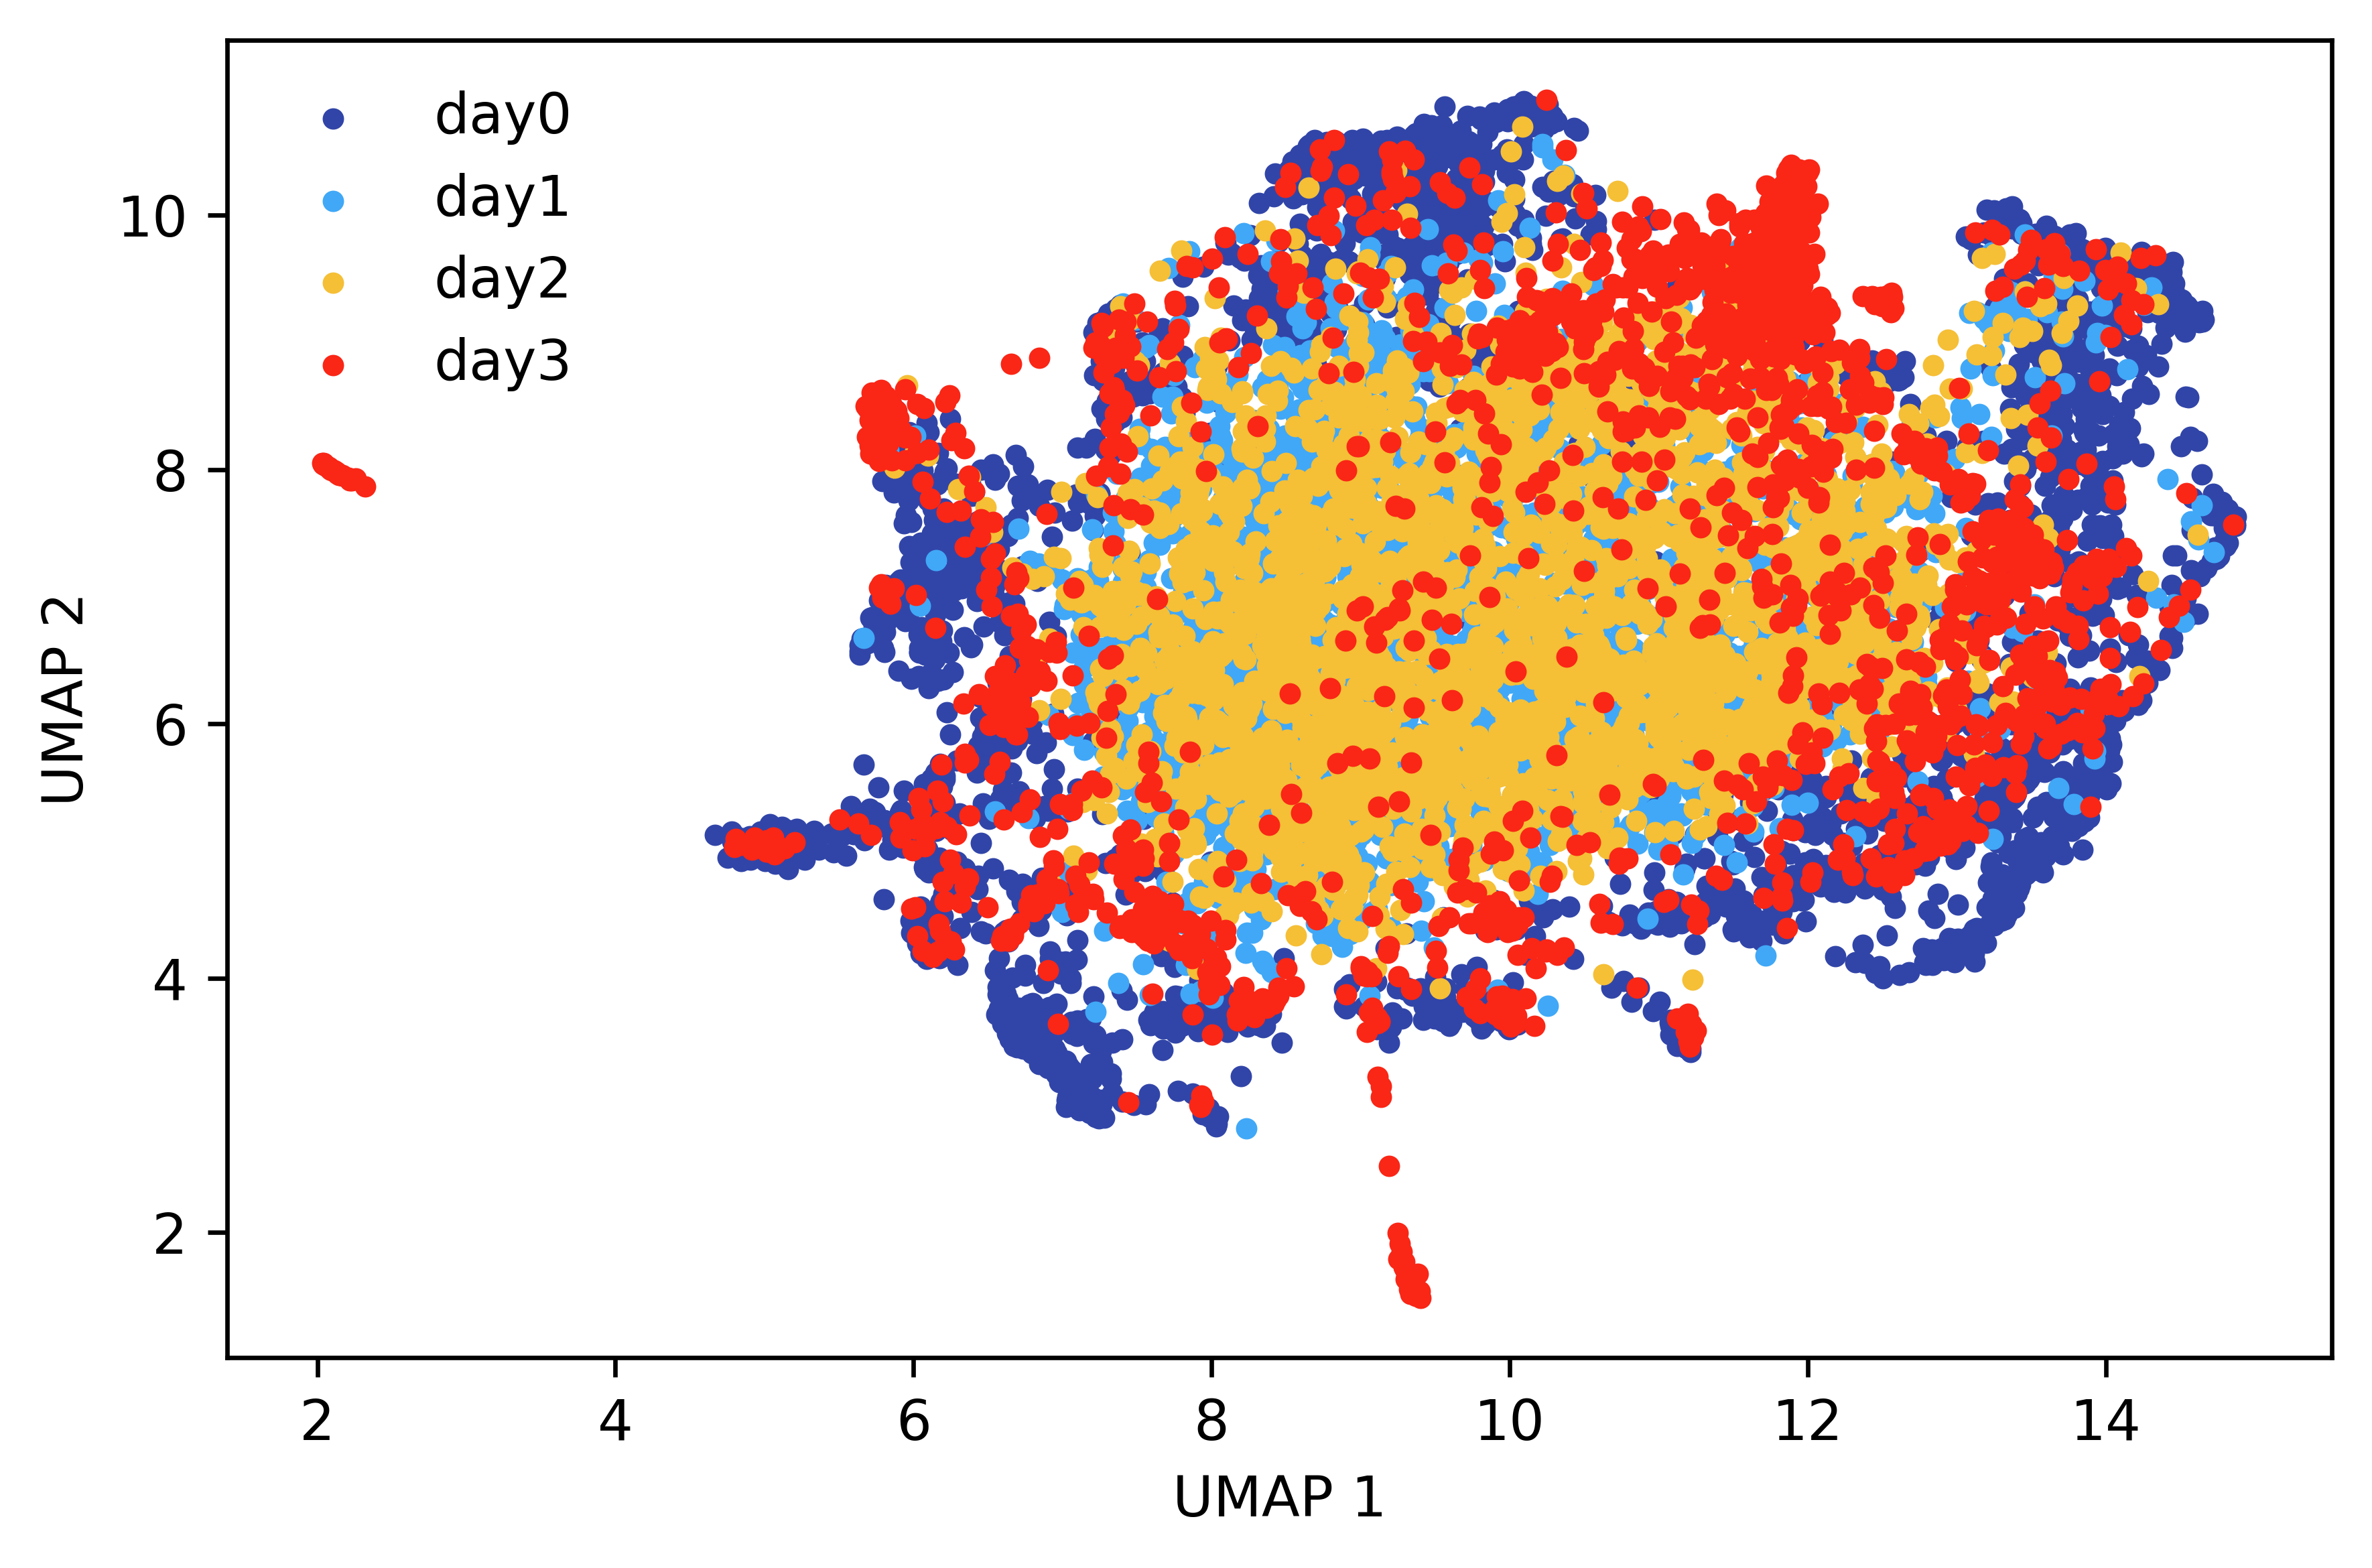

In [21]:
from sklearn.decomposition import PCA
import umap

combined_points = np.concatenate([
    sample_interp0.detach().cpu().numpy(),
    sample_interp1.detach().cpu().numpy(),
    sample_interp2.detach().cpu().numpy(),
    sample_interp3.detach().cpu().numpy(),
], axis=0)
combined_labels = np.concatenate([
    np.full(sample_interp0.shape[0], 0),
    np.full(sample_interp1.shape[0], 1),
    np.full(sample_interp2.shape[0], 2),
    np.full(sample_interp3.shape[0], 3),
])

pca_result = PCA(n_components=min(30, combined_points.shape[1])).fit_transform(combined_points)
embedding_combined = umap.UMAP(n_neighbors=50, min_dist=0.2, n_components=2).fit_transform(pca_result)

plt.figure(figsize=(6, 4), dpi=600)
colorlist = ['#3145a8', '#40a8f7', '#f5bf36', '#fa2616']
for i in range(4):
    plt.scatter(
        embedding_combined[combined_labels == i, 0],
        embedding_combined[combined_labels == i, 1],
        c=colorlist[i],
        s=8,
        alpha=1,
        label=f'day{i}',
    )
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
sampler.cal_metric(sample_interp0, test_rna_paired[test_rna_paired.obs['Group'] == 0])


In [ ]:
sampler.cal_metric(sample_interp1, test_rna_paired[test_rna_paired.obs['Group'] == 1])


In [ ]:
sampler.cal_metric(sample_interp2, test_rna_paired[test_rna_paired.obs['Group'] == 2])


## 8. Differential Gene Expression and Heatmap (Fig. 2d)

Wilcoxon rank-sum differential expression analysis is applied to predicted cells grouped by time point. The top 15 DE genes per group are visualized as a scaled matrix plot. Key marker genes (NANOG, GATA6, T) are highlighted in a dot plot to confirm biological relevance of the predictions, corresponding to Fig. 2d.


In [ ]:
sampler.cal_metric(sample_interp3, test_rna_paired[test_rna_paired.obs['Group'] == 3])


### 8.1 Matrix Plot of Top 15 DE Genes per Day


In [ ]:
pred_tensor = np.array(torch.cat([sample_interp0, sample_interp1, sample_interp2, sample_interp3], dim=0).detach().cpu())
all_new_data = anndata.AnnData(pred_tensor)
all_new_data.obs['weights'] = combined_labels.astype(str)
all_new_data.obs['weights'] = all_new_data.obs['weights'].astype('category')
all_new_data.var_names = test_rna_paired.var_names

sc.tl.rank_genes_groups(all_new_data, groupby='weights', method='wilcoxon')
all_new_data.layers['scaled'] = sc.pp.scale(all_new_data, copy=True).X
marker_genes_dict = {
    '0': ['T', 'GATA6', 'NANOG'],
}


### 8.2 Dot Plot of Key Marker Genes (NANOG, GATA6, T)


In [ ]:
fig, ax = plt.subplots(figsize=(9, 8), dpi=800)
sc.pl.rank_genes_groups_matrixplot(
    all_new_data,
    dendrogram=False,
    n_genes=15,
    use_raw=False,
    swap_axes=True,
    vmin=-1,
    vmax=1,
    cmap='RdBu_r',
    layer='scaled',
    ax=ax,
    show=False,
)


## 9. Pseudotime Analysis (Fig. 2e)

### Purpose of This Experiment

The core goal is to validate that the intermediate cell states predicted by Squidiff are **biologically meaningful**, not just mathematical interpolations. Since the model was trained **only on Day 0 and Day 3 data**, if the predicted Day 1 and Day 2 cells produce a correct differentiation trajectory under independent pseudotime analysis, it demonstrates that the model has truly learned the underlying biology.

### What the Paper Says (Results Section)

> *"By applying pseudotime analysis (Methods) to the combined input data from day 0 and the model-predicted data from days 1 to 3, we observed matched fluctuations in cell proportions, with a continuous decline in NANOG expression and a corresponding increase in GATA6 expression (Fig. 2e,f)."*

> *"We further examined the gene TBXT (T/brachyury), a mesodermal marker, which was enriched on days 1 and 2, indicating its role in early mesoderm differentiation (Fig. 2e,f). These findings underscore the nonlinearity of gene expression dynamics during developmental processes and show that Squidiff learns gene relationships."*

### How to Read the KDE Density Plot (Fig. 2e Top Panel)

- **X-axis (Pseudotime)**: 0 = iPSC undifferentiated state, 1 = fully differentiated (definitive endoderm)
- **Y-axis (Density)**: relative cell density at each pseudotime position
- **Dark blue (Day 0)**: peak ~0.2, cells concentrate at early pseudotime
- **Light blue (Day 1)**: peak ~0.3, slight rightward shift from Day 0
- **Orange (Day 2)**: flat distribution spanning ~0.3-1.0, reflecting heterogeneous transitional states
- **Red (Day 3)**: peaks at ~0.6 and ~0.9, cells have differentiated to later stages

### Key Conclusions

1. **Temporal order matches pseudotime direction**: density peaks shift progressively left to right (Day 0 -> 3)
2. **Predicted intermediates are biologically valid**: Day 1 and Day 2 cells (predicted, not observed) fall at correct intermediate positions
3. **Day 2's flat distribution** reflects high heterogeneity in the transitional state, consistent with biological expectations

### Pseudotime Method

The pseudotime values were computed using **Scorpius** (an R package for unsupervised linear pseudotime trajectory inference from scRNA-seq data). Scorpius uses k-means clustering -> distance matrix -> shortest path -> principal curve fitting to assign each cell a pseudotime value between 0 and 1.

Pseudotime values from a previous Scorpius run (`figure2_dataset1_time_1022.csv`) are projected onto predicted cells. This step requires the pre-computed pseudotime CSV from the original analysis. If unavailable, this cell is skipped gracefully.

> **To enable**: download `figure2_dataset1_time_1022.csv` from the paper's supplementary materials, or recompute using Scorpius (R) / `sc.tl.dpt()` (scanpy, Python) on the combined day 0-3 predictions (`all_new_data`).


In [ ]:
fig, ax = plt.subplots(figsize=(3.5, 4), dpi=800)
sc.pl.dotplot(
    all_new_data,
    marker_genes_dict,
    'weights',
    vmin=0,
    vmax=3.5,
    dendrogram=False,
    ax=ax,
    cmap='Blues',
)


### 9.1 KDE Density Plot Along Pseudotime

Kernel density estimation plots show the distribution of each day's cells along the pseudotime axis. Expected pattern: day 0 cells cluster near pseudotime=0 and day 3 cells near pseudotime=1, with intermediate states between them.


In [ ]:
pseudotime_candidates = [
    os.path.join(REPO_ROOT, 'figure2_dataset1_time_1022.csv'),
    os.path.join(REPO_ROOT, 'config', 'figure2_dataset1_time_1022.csv'),
]

p_time = None
pseudotime_source = None
for candidate in pseudotime_candidates:
    if os.path.exists(candidate):
        p_time = pd.read_csv(candidate, index_col=0)
        pseudotime_source = candidate
        break

if p_time is not None:
    all_new_data.obs['Pseudotime'] = np.asarray(p_time).reshape(-1)
    print(f'Pseudotime assigned from {pseudotime_source}.')

    hex_colors = ['#3145a8', '#40a8f7', '#f5bf36', '#fa2616']
    plt.figure(figsize=(3, 1), dpi=800)
    sns.kdeplot(
        data=all_new_data.obs,
        x='Pseudotime',
        hue='weights',
        bw_adjust=.8,
        palette=hex_colors,
        linewidth=2,
        common_norm=False,
    )
    plt.legend().set_visible(False)
    plt.xlabel('Pseudotime')
    plt.ylabel('Density')
    plt.xlim([0, 1])
    plt.tight_layout()
    plt.show()
else:
    print('Skipping pseudotime: figure2_dataset1_time_1022.csv not found.')


## Notes

- **plot_util**: This module is not included in the public repository. It provides `plot_pca()` and `display_reconst()` used in Sections 3 and 4. If unavailable, those cells will raise an ImportError — the remaining cells are unaffected.
- **Gene size**: 203 genes (top 200 HVG + NANOG + T + GATA6) must match the training run.
- **Group column**: The `Group` column in train/test AnnData uses integer day indices (0, 1, 2, 3) rather than string labels (`day0`, etc.). Ensure this is consistent with the preprocessing step.
- **Pseudotime CSV**: `figure2_dataset1_time_1022.csv` was pre-computed by the paper authors using Scorpius. To recompute, apply Scorpius to the combined predicted dataset.
- **Output files**: Metric CSVs are saved to `outputs/fig2_diff_r_all_new.csv` and `outputs/fig2_diff_pearsonr_all_new.csv` for downstream comparison.
